In [56]:
# import h5py
# import numpy as np

# # Getting the data
# path = "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5"
# f = h5py.File(path, "r")
# x, y = [], []
# for demo in f["data"].keys():
#     x.append(np.array(f[f"data/{demo}/datagen_info/object_poses/plate_601"])[0, 0, 3])
#     y.append(np.array(f[f"data/{demo}/datagen_info/object_poses/plate_601"])[0, 1, 3])
# x = np.array(x)
# y = np.array(y)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# fig_width = 1280 / 100  # = 12.8 inches
# fig_height = 720 / 100  # = 7.2 inches

# # # Example: replace with your actual data
# # x = np.random.normal(6.7, 0.8, 100)
# # y = np.random.normal(-0.5, 1.0, 100)

# # Create the plot
# plt.figure(figsize=(12.8, 7.2), dpi=100)
# sns.kdeplot(x=x, y=y, fill=True, cmap="Blues", bw_adjust=0.3, levels=50, thresh=0.05)
# # plt.scatter(x, y, c='orange', s=20)

# # Set plot limits and labels
# plt.xlim(6.7 - 3.5, 6.7 + 3.5)
# plt.ylim(-0.5 - 2.25, -0.5 + 2.25)
# plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()
# plt.xlabel("x (m)")
# plt.ylabel("y (m)")
# plt.tight_layout()
# plt.show()

In [1]:
import json
import h5py
import omnigibson as og
import torch as th
th.set_printoptions(precision=3, sci_mode=False)
import numpy as np
np.set_printoptions(precision=3, suppress=True)
from omnigibson.macros import create_module_macros
from omnigibson.action_primitives.starter_semantic_action_primitives import StarterSemanticActionPrimitives
import omnigibson.utils.transform_utils as T
from scipy.spatial.transform import Rotation as R
import omnigibson.lazy as lazy
from omnigibson import object_states
from omnigibson.objects.primitive_object import PrimitiveObject
from omnigibson.objects.dataset_object import DatasetObject


seed = 0
np.random.seed(seed)
th.manual_seed(seed)

# Load the scene from the hdf5 file
f = h5py.File("/home/arpit/test_projects/OmniGibson/teleop_collected_data/r1_tidy_table.hdf5", "r")
config = f["data"].attrs["config"]
config = json.loads(config)

# Custom changes
config["scene"]["load_room_instances"] = ["kitchen_0", "dining_room_0", "entryway_0", "living_room_0"]
config["robots"][0]["position"] = [0.0, 0.0, 0.0]
config["robots"][0]["orientation"] = [0.0, 0.0, 0.0, 1.0]

env = og.Environment(configs=config)

# Read the file
file_name = "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_tidy_table_momagen/demo_src_r1_tidy_table_task_D2/demo.hdf5"
f = h5py.File(file_name, "r")


# Set camera
rot = R.from_euler("xyz", [0, 0, 180], degrees=True).as_quat()
og.sim.viewer_camera.set_position_orientation(
    position=th.tensor([6.611, -0.667,  4.950]),
    orientation=th.tensor(rot)
)
og.sim.viewer_camera.horizontal_aperture = 31.0


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


[INFO] [omnigibson.simulator] ----- Starting OmniGibson. This will take 10-30 seconds... -----


[Warning] [simulation_app] Interactive python shell detected but ISAAC_JUPYTER_KERNEL was not set. Problems with asyncio may occur
[Warning] [simulation_app] Please use Isaac Sim Python 3 kernel instead of the default Python 3 Kernel
Starting kit application with the following args:  ['/home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/isaacsim/exts/isaacsim.simulation_app/isaacsim/simulation_app/simulation_app.py', '/home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/isaacsim/apps/omnigibson_4_5_0.kit', '--/app/tokens/exe-path=/home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/omni', '--/persistent/app/viewport/displayOptions=3094', '--/rtx/materialDb/syncLoads=True', '--/rtx/hydra/materialSyncLoads=True', '--/omni.kit.plugin/syncUsdLoads=True', '--/app/renderer/resolution/width=1280', '--/app/renderer/resolution/height=720', '--/app/window/width=1440', '--/app/window/height=900', '--/renderer/multiGpu/enabled=F

2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 16 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 17 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 18 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 19 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 20 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 21 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 22 belongs to.
2025-05-15 19:45:57 s] [Error] [omni.platforminfo.plugin] failed to find the package that core 23 belongs to.



|---------------------------------------------------------------------------------------------|
| Driver Version: 550.54.14     | Graphics API: Vulkan
|=============================================================================================|
| GPU | Name                             | Active | LDA | GPU Memory | Vendor-ID | LUID       |
|     |                                  |        |     |            | Device-ID | UUID       |
|     |                                  |        |     |            | Bus-ID    |            |
|---------------------------------------------------------------------------------------------|
| 0   | NVIDIA GeForce RTX 4090          | Yes: 0 |     | 24564   MB | 10de      | 0          |
|     |                                  |        |     |            | 2684      | ece2eaa7.. |
|     |                                  |        |     |            | 1         |            |
|===============================================================================

...

2025-05-15 19:46:28 [31,018ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__base_link/Shader' parameter 'normalmap_texture': References an asset that can not be found: './../material/ffitak__base_link__normal.png'
2025-05-15 19:46:28 [31,018ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__base_link/Shader' parameter 'metallic_texture': References an asset that can not be found: './../material/ffitak__base_link__metalness.png'
2025-05-15 19:46:28 [31,018ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__base_link/Shader' parameter 'reflectionroughness_texture': References an asset that can not be found: './../material/ffitak__base_link__roughness.png'
2025-05-15 19:46:28 [31,018ms] [Error] [omni.hydra] [UsdToMdl] Prim '/World/scene_0/oven_ffitak_0/Looks/ffitak__base_link/Shader' parameter 'diffuse_texture': References an asset that can not be found: './../material/ffitak__base_link_

2025-05-15 19:46:38 [41,448ms] [Warning] [omni.syntheticdata.plugin] SdRenderVarPtr missing valid input renderVar LdrColorSDhost


2025-05-15 19:46:39 [41,998ms] [Error] [omni.kit.app._impl] [py stderr]: /home/arpit/mambaforge/envs/mimicgen-isaac-4.5/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[INFO] [omnigibson.simulator] Imported scene 0.


[WARNING] [Comm] No such comm: ad787acee558486ab61825895ecdd89b


2025-05-15 19:46:48 [50,885ms] [Warning] [Comm] No such comm: ad787acee558486ab61825895ecdd89b


In [2]:
# Hide objects
for obj in env.scene.object_registry("category", "room_light"):
    obj.visible = False
for obj in env.scene.object_registry("category", "ceilings"):
    obj.visible = False
for obj in env.scene.object_registry("category", "range_hood"):
    obj.visible = False
for obj in env.scene.object_registry("category", "downlight"):
    obj.visible = False
for obj in env.scene.object_registry("category", "taboret"):
    obj.visible = False

obj = env.scene.object_registry("name", "top_cabinet_lkxmne_0")
obj.visible = False
obj = env.scene.object_registry("name", "shelf_pfusrd_0")
obj.visible = False
obj = env.scene.object_registry("name", "teacup_601")
obj.visible = False
for _ in range(50): og.sim.step()

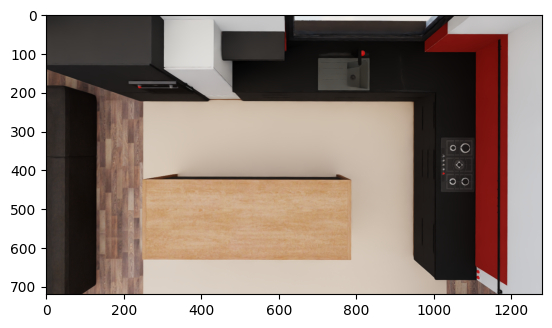

In [3]:
import matplotlib.pyplot as plt
viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
plt.imshow(viewer_camera_img)
plt.show()

In [19]:
# For multiple task-relevant objects

import seaborn as sns
palette = sns.color_palette("deep")    
color = th.cat((th.tensor(palette[0]), th.tensor([1.0])))

# paths = ["/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5",
#         "/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_dishes_away_ablation_only_soft/demo_src_r1_dishes_away_task_D0/demo.hdf5"]
# objects = ["plate_601", "plate_602", "plate_603"]

paths = ["/home/arpit/test_projects/mimicgen/datasets/generated_data_mimicgen_format/core_datasets_og/r1_tidy_table_momagen/demo_src_r1_tidy_table_task_D2/demo.hdf5"]
objects = ["teacup_601"]

marker_list = []
marker_counter = 0

for path_j, path in enumerate(paths):
    f = h5py.File(path, "r")
    num_demos = len(f["data"].keys())
    # If D0/D1 wise color
    color = th.cat((th.tensor(palette[path_j]), th.tensor([1.0])))
    for obj_j, obj in enumerate(objects):
        # color = th.cat((th.tensor(palette[obj_j]), th.tensor([1.0])))
        for i in range(num_demos):
            marker = PrimitiveObject(
                relative_prim_path=f"/marker_{marker_counter}",
                name=f"marker_{marker_counter}",
                primitive_type="Cylinder",
                # size=th.tensor([0.05, 0.05, 0.05]),
                radius=0.05,
                height=0.02,
                visual_only=True,
                rgba=color
            )
            marker_list.append(marker)
            marker_counter += 1


og.sim.batch_add_objects(marker_list, [env.scene] * len(marker_list))

marker_counter = 0
for obj in objects:
    for i in range(num_demos):
        pos = f["data"][f"demo_{i}"]["datagen_info"]["object_poses"][obj][0][:3,3]
        if obj == "plate_603":
            pos += np.array([0.0, 0.0, 0.1])
        marker_list[marker_counter].set_position_orientation(position=pos)
        marker_counter += 1

for _ in range(50): og.sim.step()

[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


2025-05-15 20:09:06 [1,389,186ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
2025-05-15 20:09:06 [1,389,319ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


2025-05-15 20:09:06 [1,389,453ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
2025-05-15 20:09:06 [1,389,586ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


...

2025-05-15 20:09:12 [1,395,110ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
2025-05-15 20:09:12 [1,395,242ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


2025-05-15 20:09:12 [1,395,379ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
2025-05-15 20:09:12 [1,395,514ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
[WARNING] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


2025-05-15 20:09:12 [1,395,648ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.
2025-05-15 20:09:12 [1,395,782ms] [Warning] [omnigibson.objects.object_base] An object's articulation root API was changed while simulation is playing. This may cause issues.


In [17]:
# If want to remove markers
og.sim.batch_remove_objects(marker_list)
for _ in range(50): og.sim.step()

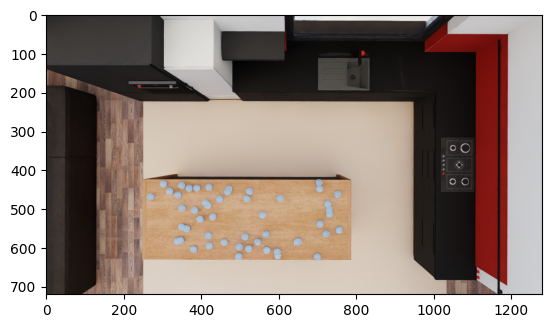

In [21]:
import matplotlib.pyplot as plt
viewer_camera_img = og.sim.viewer_camera.get_obs()[0]["rgb"][:, :, :3]
plt.imshow(viewer_camera_img)
plt.show()
path = "/home/arpit/test_projects/mimicgen/paper_assets"
plt.imsave(f'{path}/diversity_fig_tidy_table_D2.jpg', viewer_camera_img.numpy())

In [103]:
# import omnigibson.lazy as lazy
# from pxr import UsdGeom, Usd
# stage = lazy.omni.usd.get_context().get_stage()
# camera_path = og.sim.viewer_camera.prim_path
# camera_prim = stage.GetPrimAtPath(camera_path)
# camera = UsdGeom.Camera(camera_prim)
# # projection = camera.GetProjectionAttr().Get()
# camera.CreateProjectionAttr().Set(UsdGeom.Tokens.perspective)
# for _ in range(100): og.sim.render()

# og.sim.viewer_camera.horizontal_aperture = 60.0
# og.sim.viewer_camera.vertical_aperture
# og.sim.viewer_camera.focal_length